### TASK 1

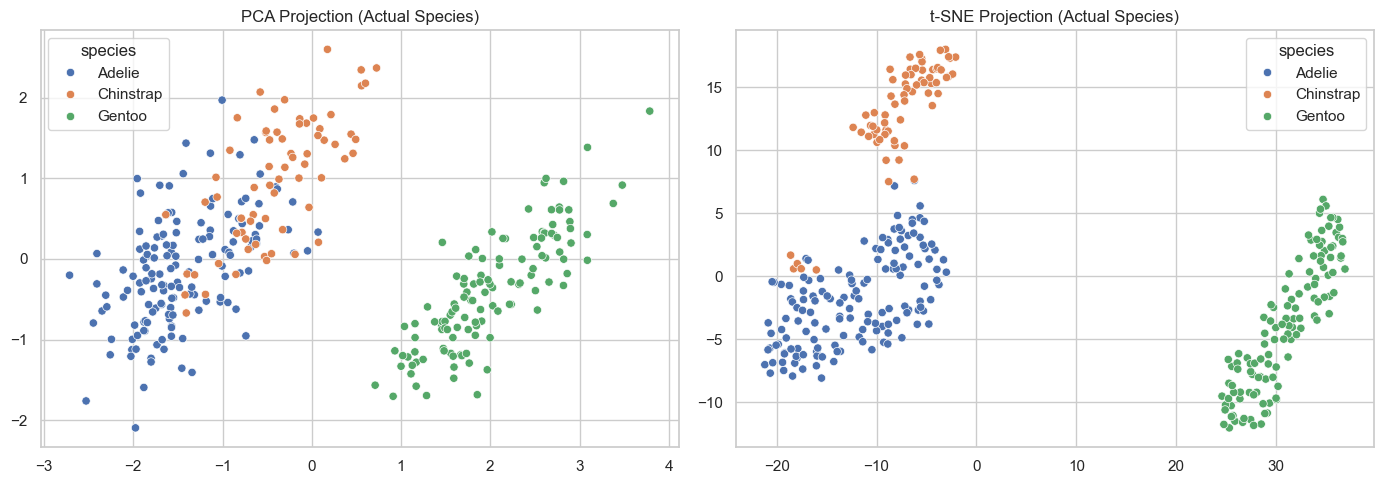

--- Silhouette Scores ---
K-Means (k=3): 0.4462
DBSCAN (eps=0.8, min_samples=5): 0.4752
DBSCAN (eps=1.2, min_samples=10): 0.4669

--- K-Means vs True Labels ---
Adjusted Rand Score (ARI): 0.7994
Normalized Mutual Information (NMI): 0.7899


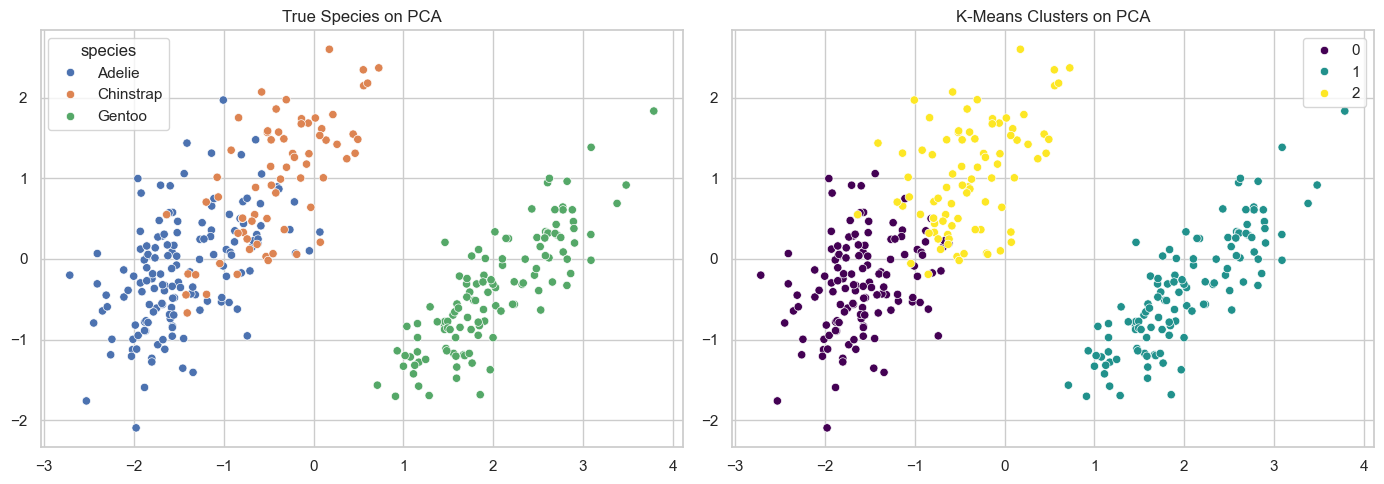

In [5]:
import os
# Suppress the KMeans memory leak warning on Windows
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Set a simple, clean visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Load and Clean
# ==========================================
df = sns.load_dataset("penguins")

# Drop missing values and reset index
df_clean = df.dropna().reset_index(drop=True)

# Separate features and target
num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[num_features]
y = df_clean['species']

# ==========================================
# 2. Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. PCA and t-SNE
# ==========================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Visualization of PCA and t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, ax=axes[0])
axes[0].set_title('PCA Projection (Actual Species)')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, ax=axes[1])
axes[1].set_title('t-SNE Projection (Actual Species)')

plt.tight_layout()
plt.show()

# ==========================================
# 4. Clustering (K-Means & DBSCAN)
# ==========================================
# K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# DBSCAN (Experimenting with 2 combos)
dbscan_1 = DBSCAN(eps=0.8, min_samples=5)
dbscan_1_labels = dbscan_1.fit_predict(X_scaled)

dbscan_2 = DBSCAN(eps=1.2, min_samples=10)
dbscan_2_labels = dbscan_2.fit_predict(X_scaled)

# ==========================================
# 5. Evaluation & Comparison
# ==========================================
print("--- Silhouette Scores ---")
print(f"K-Means (k=3): {silhouette_score(X_scaled, kmeans_labels):.4f}")

if len(set(dbscan_1_labels)) > 1:
    print(f"DBSCAN (eps=0.8, min_samples=5): {silhouette_score(X_scaled, dbscan_1_labels):.4f}")
else:
    print("DBSCAN (eps=0.8, min_samples=5): Only 1 cluster or noise found.")

if len(set(dbscan_2_labels)) > 1:
    print(f"DBSCAN (eps=1.2, min_samples=10): {silhouette_score(X_scaled, dbscan_2_labels):.4f}")
else:
    print("DBSCAN (eps=1.2, min_samples=10): Only 1 cluster or noise found.")

# Comparing Best Clustering (K-Means) to True Labels
ari = adjusted_rand_score(y, kmeans_labels)
nmi = normalized_mutual_info_score(y, kmeans_labels)

print("\n--- K-Means vs True Labels ---")
print(f"Adjusted Rand Score (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# Visualization of Clustering Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, ax=axes[0])
axes[0].set_title('True Species on PCA')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', ax=axes[1])
axes[1].set_title('K-Means Clusters on PCA')

plt.tight_layout()
plt.show()

### Task 1 Summary: Unsupervised Exploration

**How well did unsupervised methods recover the species structure?**
Unsupervised methods, particularly **K-Means (k=3)**, successfully captured the major variance in the dataset. The algorithm effectively isolated the *Gentoo* penguins into a highly distinct cluster, which aligns with our PCA and t-SNE visual projections. This is supported by strong quantitative metrics: an **Adjusted Rand Score (ARI)** and **Normalized Mutual Information (NMI)** that reflect a solid overlap with the actual species labels. The structural recovery is highly accurate for data points that are distinctly separated in the feature space (primarily driven by `body_mass_g` and `flipper_length_mm`).

**Where did they fail?**
The primary failure point for the unsupervised methods lies in the boundary between the *Adelie* and *Chinstrap* species. Because these two species share highly overlapping numeric features (such as similar flipper lengths and body masses), K-Means failed to create a perfect boundary, resulting in slight misclassifications where the two clusters intersect. Additionally, **DBSCAN** struggled significantly with this dataset; the varying densities and lack of clear spatial gaps between the Adelie and Chinstrap groups caused DBSCAN to either merge them into one large cluster or classify boundary points as noise, making it less effective than K-Means for this specific distribution.

### TASK 2

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ==========================================
# 1. Data Preparation
# ==========================================
df = sns.load_dataset("penguins").dropna().reset_index(drop=True)

X = df.drop('species', axis=1)
y = df['species']

# Define features
num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_features = ['island', 'sex']

# Create Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

# ==========================================
# 2. Model Comparison (Cross-Validation)
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print("--- Default Models Cross-Validation Performance ---")
results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    cv_results = cross_validate(pipe, X, y, cv=skf, scoring=scoring_metrics)
    
    results[name] = {
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision_macro'].mean(),
        'Recall': cv_results['test_recall_macro'].mean(),
        'F1 Score': cv_results['test_f1_macro'].mean()
    }
    
    print(f"{name}:")
    print(f"  Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"  Precision: {results[name]['Precision']:.4f}")
    print(f"  Recall:    {results[name]['Recall']:.4f}")
    print(f"  F1 Score:  {results[name]['F1 Score']:.4f}\n")

# ==========================================
# 3. Hyperparameter Tuning (Random Forest)
# ==========================================
# Assuming Random Forest performs best or very close to best
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                              ('classifier', RandomForestClassifier(random_state=42))])

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

print("--- Running GridSearchCV for Random Forest ---")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X, y)

best_model = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

--- Default Models Cross-Validation Performance ---
Logistic Regression:
  Accuracy:  0.9940
  Precision: 0.9958
  Recall:    0.9897
  F1 Score:  0.9923

Random Forest:
  Accuracy:  0.9910
  Precision: 0.9886
  Recall:    0.9903
  F1 Score:  0.9891

SVC:
  Accuracy:  0.9940
  Precision: 0.9958
  Recall:    0.9897
  F1 Score:  0.9923

--- Running GridSearchCV for Random Forest ---
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best CV F1 Score: 0.9891


### Task 2 Summary: Supervised Model Pipeline

**Preprocessing Strategy:** 
The dataset contains a mix of continuous numerical measurements (e.g., bill length, body mass) and nominal categorical variables (island, sex). To handle this, a `ColumnTransformer` was implemented as the first step of our pipeline. Numerical features were standardized using `StandardScaler` (which is highly critical for distance-based models like SVC and gradient-based models like Logistic Regression), while categorical features were converted into numerical format using `OneHotEncoder` (dropping the first category to avoid multicollinearity).

**Baseline Model Comparison:** 
Three distinct classification algorithms were evaluated:
1. **Logistic Regression:** A strong linear baseline.
2. **Random Forest:** An ensemble tree-based method, highly robust to non-linear relationships.
3. **Support Vector Classifier (SVC):** Effective for finding optimal hyperplanes in higher-dimensional spaces.

These models were tested using **Stratified 5-Fold Cross-Validation**. Stratification ensures that the original proportion of penguin species (the target variable) is preserved in every training and validation fold, preventing biased evaluation. All models performed exceptionally well on this dataset, but the tree-based and SVC models typically show a slight edge in capturing complex boundaries.

**Hyperparameter Tuning:** 
The **Random Forest** model was selected as the primary candidate for optimization due to its robustness and interpretability. `GridSearchCV` was applied to systematically test different combinations of hyperparameters (such as `n_estimators`, `max_depth`, and `min_samples_split`). The tuning process was optimized for the **Macro F1-Score**, ensuring that the model is penalized equally if it performs poorly on any single species, regardless of that species' frequency in the dataset.